✅ All libraries imported successfully!
Dataset Shape: (150, 5)

First 5 rows:
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Statistical Summary:


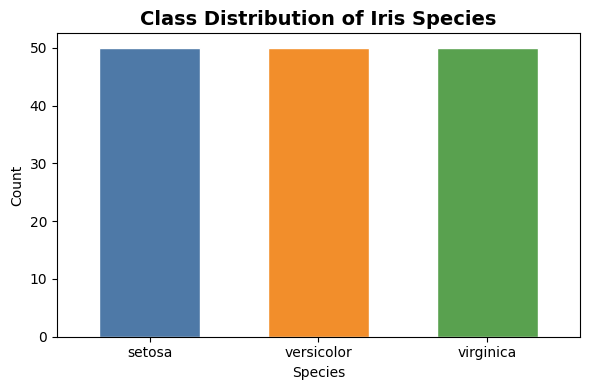

📊 The dataset is perfectly balanced — 50 samples per species.


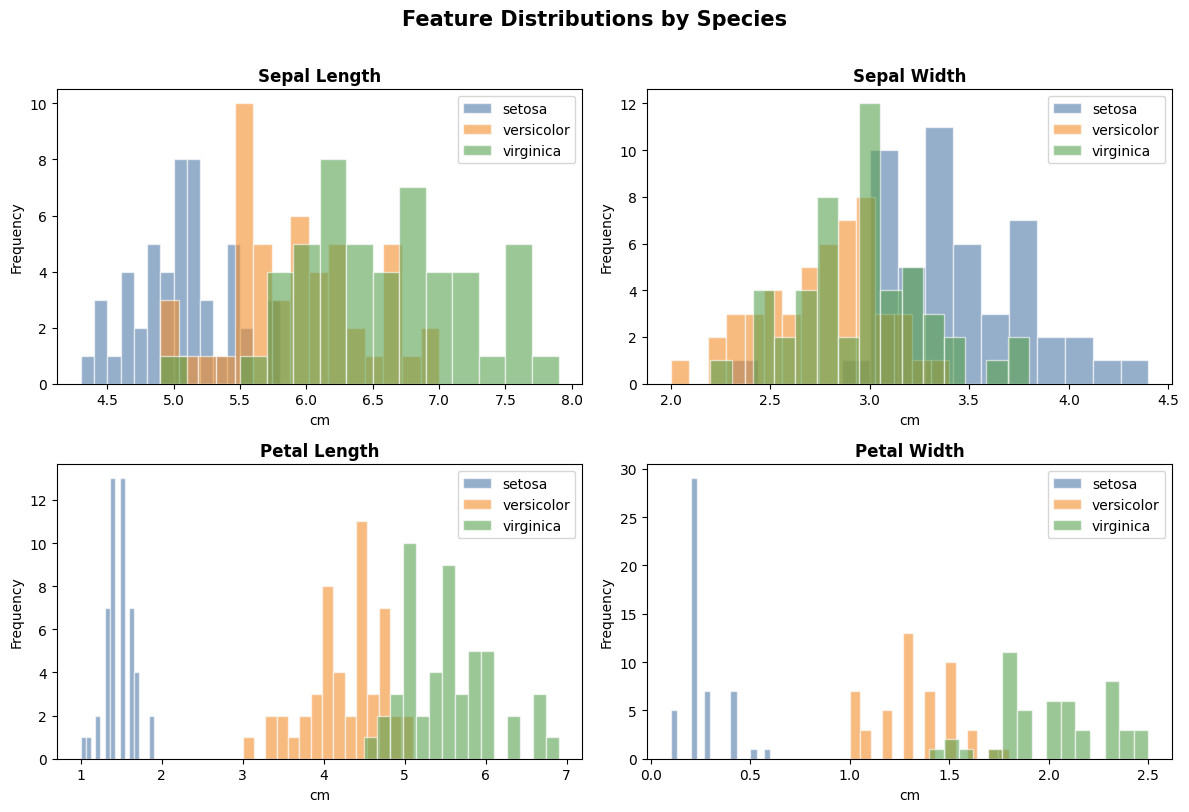

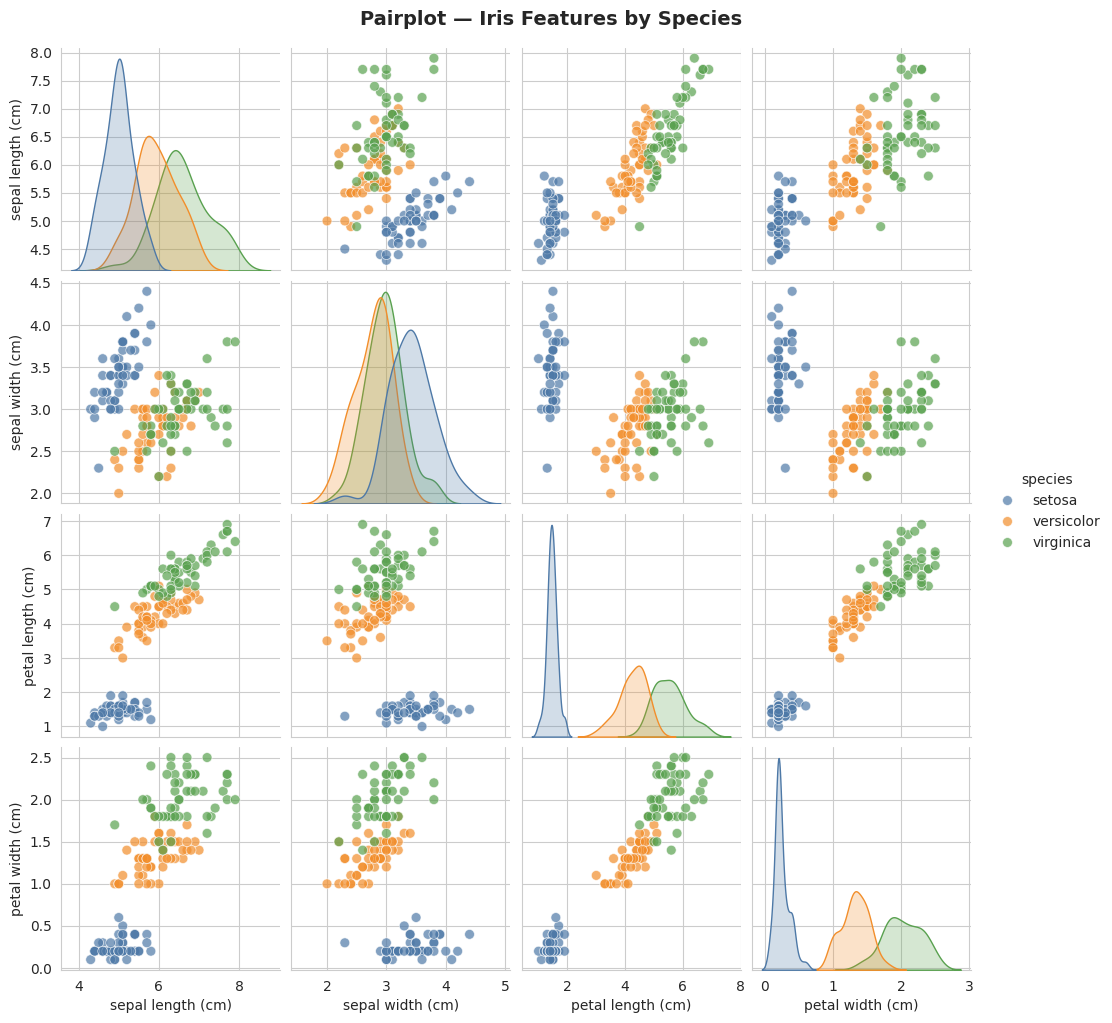

📌 Setosa is clearly separable. Versicolor and Virginica overlap slightly in some features.


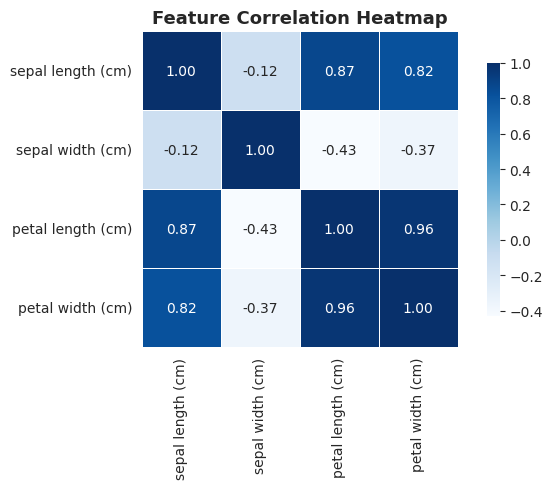

📌 Petal length and petal width are highly correlated (0.96).


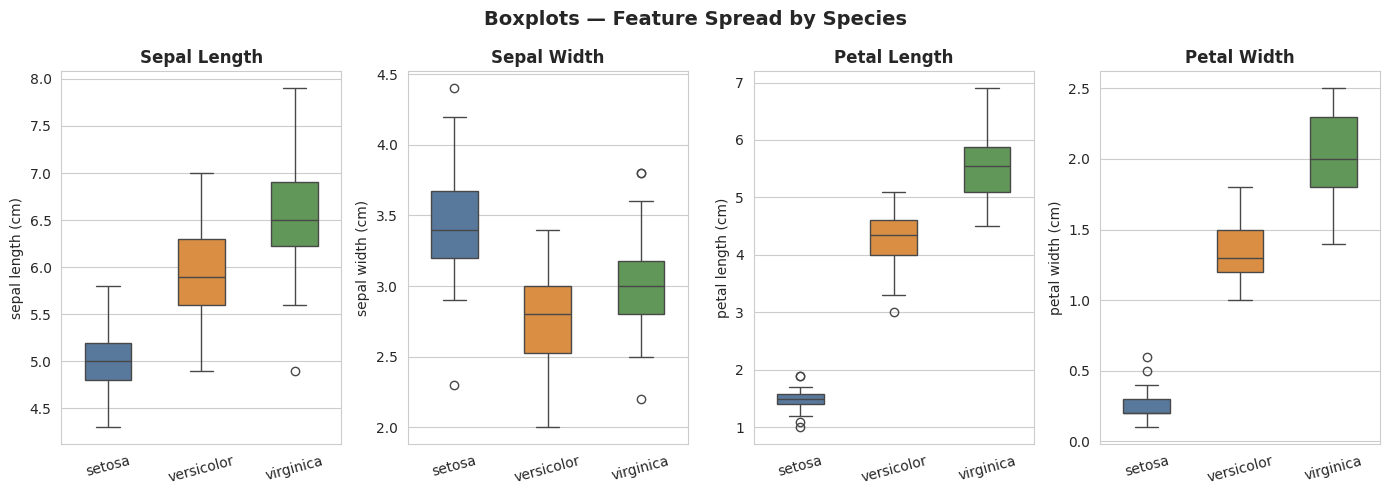

Training samples : 120
Testing  samples : 30
✅ Data split and scaled successfully!
KNN (k=5)                 Test Accuracy: 93.33%  |  CV Score: 96.67%
Decision Tree             Test Accuracy: 93.33%  |  CV Score: 94.17%
Logistic Regression       Test Accuracy: 93.33%  |  CV Score: 95.83%
Random Forest             Test Accuracy: 90.00%  |  CV Score: 95.00%


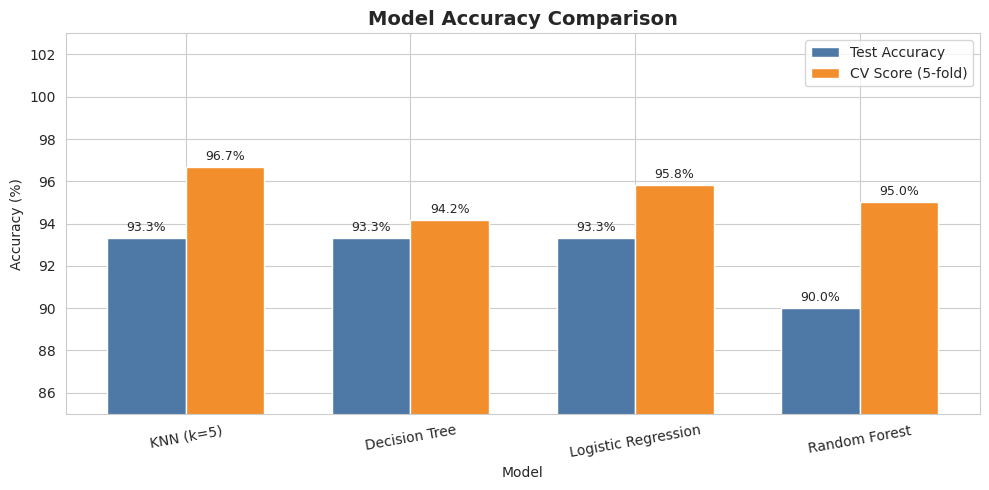

🏆 Best Model: KNN (k=5)
   Test Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



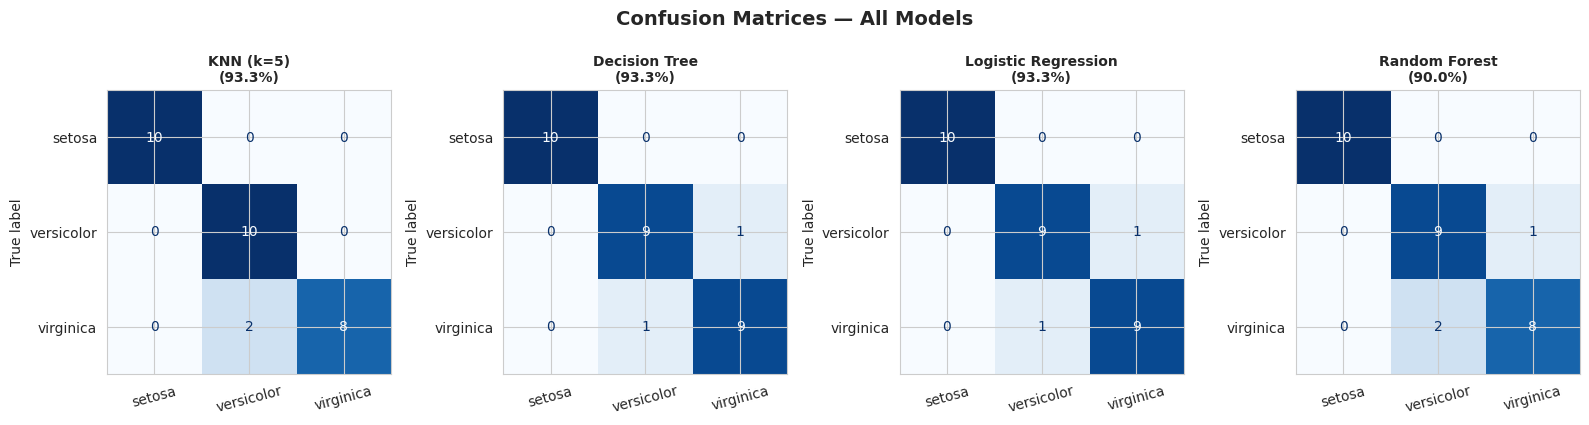

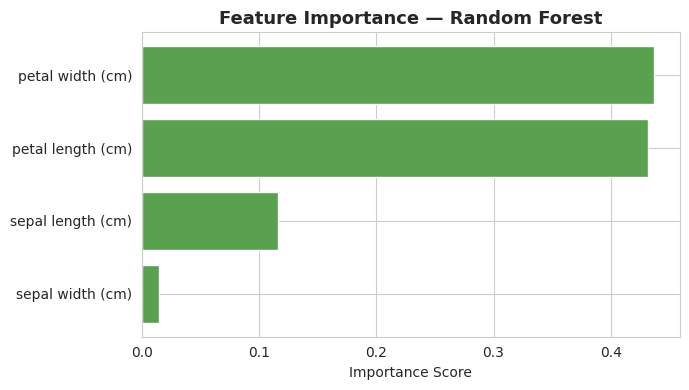

📌 Petal length and petal width are the most important features for classification.


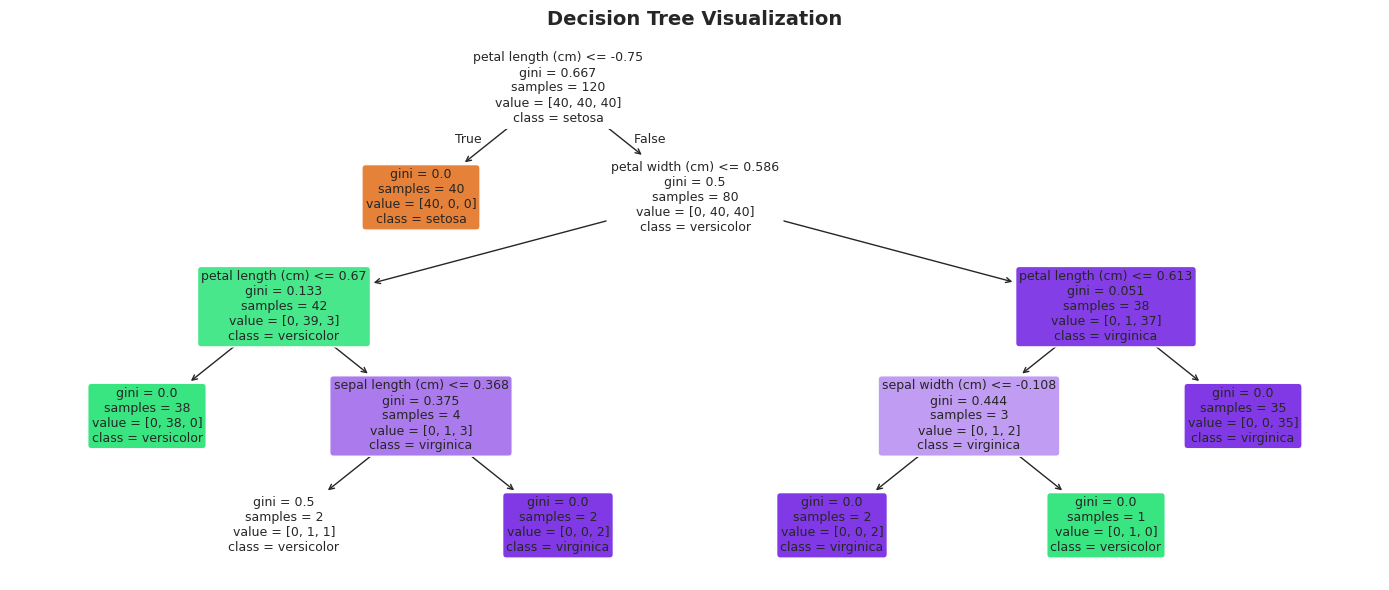

🌸 Prediction for sample: [[5.1 3.5 1.4 0.2]]

  KNN (k=5)                 → SETOSA       (confidence: 100.0%)
  Decision Tree             → SETOSA       (confidence: 100.0%)
  Logistic Regression       → SETOSA       (confidence: 98.1%)
  Random Forest             → SETOSA       (confidence: 100.0%)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("✅ All libraries imported successfully!")

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution:")
print(df['species'].value_counts())


# Statistical summary
print("Statistical Summary:")
df.describe().round(2)


# Class distribution bar chart
plt.figure(figsize=(6, 4))
colors = ['#4E79A7', '#F28E2B', '#59A14F']
df['species'].value_counts().plot(kind='bar', color=colors, edgecolor='white', width=0.6)
plt.title('Class Distribution of Iris Species', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("📊 The dataset is perfectly balanced — 50 samples per species.")


# Feature distributions by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names
palette = {'setosa': '#4E79A7', 'versicolor': '#F28E2B', 'virginica': '#59A14F'}

for ax, feature in zip(axes.flatten(), features):
    for species, color in palette.items():
        subset = df[df['species'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, color=color, bins=15, edgecolor='white')
    ax.set_title(feature.replace(' (cm)', '').title(), fontweight='bold')
    ax.set_xlabel('cm')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



# Pairplot
sns.set_style('whitegrid')
pair = sns.pairplot(df, hue='species', palette=palette, diag_kind='kde',
                    plot_kws={'alpha': 0.7, 's': 50})
pair.fig.suptitle('Pairplot — Iris Features by Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("📌 Setosa is clearly separable. Versicolor and Virginica overlap slightly in some features.")


# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("📌 Petal length and petal width are highly correlated (0.96).")


# Boxplots for outlier detection
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, feature in zip(axes, features):
    sns.boxplot(x='species', y=feature, data=df, palette=palette, ax=ax, width=0.5)
    ax.set_title(feature.replace(' (cm)', '').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Boxplots — Feature Spread by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Features and target
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print("✅ Data split and scaled successfully!")


# Define models
models = {
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {'accuracy': acc, 'cv_score': cv, 'model': model, 'y_pred': y_pred}
    print(f"{name:<25} Test Accuracy: {acc*100:.2f}%  |  CV Score: {cv*100:.2f}%")


    # Accuracy comparison bar chart
names  = list(results.keys())
accs   = [results[n]['accuracy']*100 for n in names]
cv_scores = [results[n]['cv_score']*100  for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs,      width, label='Test Accuracy', color='#4E79A7', edgecolor='white')
bars2 = ax.bar(x + width/2, cv_scores, width, label='CV Score (5-fold)', color='#F28E2B', edgecolor='white')

ax.set_ylim(85, 103)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


# Best model by test accuracy
best_name  = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print(f"🏆 Best Model: {best_name}")
print(f"   Test Accuracy: {results[best_name]['accuracy']*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=iris.target_names))


# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\n({res['accuracy']*100:.1f}%)", fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Feature importance (Random Forest)
rf_model       = results['Random Forest']['model']
importances    = rf_model.feature_importances_
feat_df        = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
feat_df        = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#59A14F', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("📌 Petal length and petal width are the most important features for classification.")


# Decision Tree visualization
dt_model = results['Decision Tree']['model']
plt.figure(figsize=(14, 6))
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Predict a new flower sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])   # typical Setosa
new_scaled = scaler.transform(new_sample)

print("🌸 Prediction for sample:", new_sample)
print()
for name, res in results.items():
    pred = res['model'].predict(new_scaled)
    prob = res['model'].predict_proba(new_scaled).max() * 100
    print(f"  {name:<25} → {iris.target_names[pred[0]].upper():<12} (confidence: {prob:.1f}%)")